# Buzz Lightyear Bitacora, fecha 4072

**02:** En esta notebook se busca maximizar la varianza entre las imagenes cortadas en cuadrantes.

**03:** Se entrena una red para cada cuadrante y al final se usa un clasificador RBF con las probabilidades de las 4 redes como entradas.  
`ul: 50, ur: 50, ll: 40, lr: 40; RBF: 45`

**04:** No se si la maximizacion de la varianza ayude o no, se pone a prueba en esta notebook, se hace cropping de los cuadrantes, sin aplicar color jittering. Le hice 100 epocas para asegurarme que no fuera por eso, resulta que empeoro el rendimiento. Supongo que el problema es el cropping.  
 `ul: 55, ur: 45, ll: 40, lr: 40; RBF: 45`

**06:** Tengo que volver a encontrar la forma de maximizar la varianza, pero ahora sin hacer cropping. Chat me dijo que buscara entre 0, 0.6, no lei la clase, pero lo hice asi.

**07:** Me di cuenta que el ColorJittering solo es random, en esta notebook lo quite e intente nuevas formas, salieron peores resultados. Tambien cambie la forma de hacer el meta-modelo, ahora se fija en los TPR de cada clase y los usa como pesos para entrenar el meta-modelo RBF. Me pone feliz que al que mejor le fue, es el que tiene color jittering.  
`ul: 45, ur: 40, ll: 50, lr: 40; RBF: 35`.

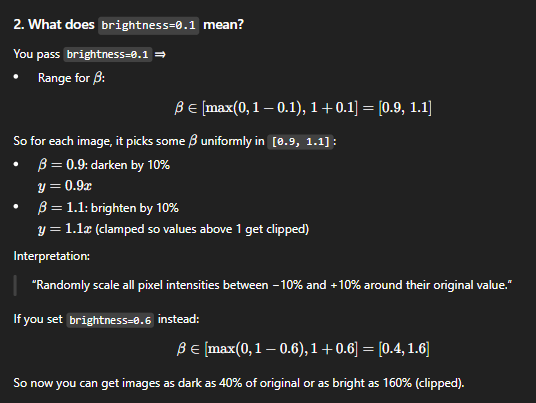

**08:** En esta notebook se vuelve a poner el ColorJittering, me pesaba no saber que hacia. No hice normalizacion, tome la imagen completa. Me doy cuenta que cuando haces los crops, el training llega a 100% muy rapido, pero generaliza mal; al tomar la imagen completa, tarda mas en llegar a 100% pero generaliza mejor. JAJAJAAJJ me da mucha risa que desde que le puse cuadrantes he estade pensando en la peli, Cuadrante Gamma del Sector 4!  
`ul: 55, ur: 55, ll: 45, lr: 45; RBF: 40`.   


**09:** Vale la pena normalizar? Mucho, si. Creo que sigo cargando desbalance de clases.  
`ul: 50, ur: 50, ll: 50, lr: 60; RBF: 40`

**10:** Un Pullock es igual si esta vertical u horizontal, tambien si tiene un flip. QUE?! PASO TODO LO CONTRARIO!

**11:** Se sobreajusta. Chat dijo que poner Conv2D y Pool2d ayudaria, tambien combio el optimizador, agrego `weight decay`, mientras voy a intentar con estos. 355 imagenes, 20 epocas.  
`ul: 63, ur: 50, ll: 55, lr:52, RBF: 44`

**12:** Agregue weight decay. Cambie la aleatoriedad del ColorJittering. Parece que lo mejor esta entre $0.0, 0.33$, son las que tuvieron mejor rendimiento.
Intente con las 355 imagenes y 40 epocas.  
`ul: 63, ur: 63, ll: 58, lr: 44; RBF: 38`

**13:** En 12, parecica que les faltaba entrenamiento, subi a 100 epocas. Parece que lo mejor es usar muy poco ColorJittering, se suaviza el entrenamiento y la validacion. Parece que no es buena ida hacer stacking con un RBF. 
`ul: 75, ur: 75, ll: 75, lr: 80; RBF: 45`

**14:** Cambie el optimizador a AdamW. Hice una arquitectura mas grande para las redes individuales. Creo que no es buena idea hacer stacking con un RBF. Imito las convolucionales con puras ReLU y Linear, creo muchisimas mas imagenes.

**15:** Intente con muchisimas epocas y no doy.

**16:** Intente imitar las convolucionales con puras ReLU y Linear, creo muchisimas mas imagenes. No doy.

**17:** Olvido entrenar muchos modelos y mejor solo hago uno muy bueno.

**18:** DeepPatchMLPNet con 20 epocas. Wow!
```
Epoch 20 | train_loss=0.4649, train_acc=0.749 | val_loss=1.4564, val_acc=0.596
Best val_acc (DeepPatchMLPNet): 0.723
```

**19:** DeepPatchMLPNet con 100 epocas. No se que hice que se sobreajusto tanto...
```
Epoch 100 | train_loss=0.0231, train_acc=0.990 | val_loss=2.0846, val_acc=0.596
Best val_acc (DeepPatchMLPNet): 0.660
```

**20:** Voy a volver a SmallConvFreeNet, pero con 100 epocas. No se sobreajusta.
```
Epoch 100 | train_loss=0.8048, train_acc=0.596 | val_loss=1.0212, val_acc=0.489
Best val_acc (SmallConvFreeNet): 0.617
```

**21:**
```
Epoch 100 | train_loss=0.6407, train_acc=0.706 | val_loss=0.8247, val_acc=0.638
Best val_acc (SmallConvFreeNet): 0.702
```

**22:** Y si entreno para categorizar los monos?
```
Epoch 100 | train_loss=1.4009, train_acc=0.483 | val_loss=1.5339, val_acc=0.447
Best val_acc (SmallConvFreeNet): 0.574
```
```
Acc: 0.6595744680851063
```

**23:** Voy a juntar todos los cuadrantes! gggg!!!!!! tiene que jalar!! wow! concatene 2 y hace magia, creo
```
Epoch 100 | train_loss=0.8136, train_acc=0.702 | val_loss=2.0014, val_acc=0.617
Best val_acc (SmallConvFreeNet): 0.702
```
```
Acc: 0.8085106382978723
```

**24:** AdamW, todas las imagenes, todas las transformaciones.
```
Epoch 100 | train_loss=0.8307, train_acc=0.693 | val_loss=1.3993, val_acc=0.660
Best val_acc (SmallConvFreeNet): 0.745
```
```
Accuracy: 0.8723404255319149
```

**25:** Volvi a intentar con DeepPatchMLPNet, pero es peor.

**26:** Lo mismo que en 24, pero cambiamos a Adam. No me gusto, es mas lento y tiene peor generalizacion.
```
Epoch 100 | train_loss=0.6296, train_acc=0.779 | val_loss=1.1969, val_acc=0.702
Best val_acc (SmallConvFreeNet): 0.787
```
```
Accuracy: 0.8085106382978723
```

**27:** Me voy a quedar con la 24, voy a ir cambiando los parametros. Subi el `lr=1e-2,`

**28:** Entrenamiento final, guardo los pesos.  

**29:** Verifico que funcionan los pesos guardados

**30:** Hago bien la validacion. La validacion es el cuadrante ul  

**31:** Hago *bien* la validacion. La validacion es el cuadrante ur  

**32:** Hago **bien** la validacion (la tenia mal porque testeaba con los flipped hahah). La validacion es el cuadrante ur  

**33:** Hago **bien** la validacion. Intento con AdamW y weight decay...

**34:** Hago **BIEN** la validacion. la media de las trasformaciones las saco sin el valdf. Tambien, a ll le hago zoom y a lr le hago blur, se me hace chistoso porque es como enfocarte en cosas diferentes!

# Loading the DataSet

In [47]:
a=1

In [48]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch, numpy as np

In [49]:
painter_to_genre = {
    "Joan": "Joan",
    "Salvador": "Salvador",
    "Rene": "Rene",
    "Pablo": "Pablo",
    "Jackson": "Jackson",
    "Rembrandt": "Rembrandt",
    "Caravaggio": "Caravaggio",
    "Camille": "Camille",
    "Alfred": "Alfred",
    "Claude": "Claude",
    "Vincent": "Vincent",  
}

genre_to_label = {
    "Joan": 0,
    "Salvador": 1,
    "Rene": 2,
    "Pablo": 3,
    "Jackson": 4,
    "Rembrandt": 5,
    "Caravaggio": 6,
    "Camille": 7,
    "Alfred": 8,
    "Claude": 9,
    "Vincent": 10,
}

In [50]:
from pathlib import Path
import pandas as pd

root = Path("08 Clasificacion de Movimientos Artisticos/data")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df = pd.DataFrame(rows)

In [51]:
# print(df['genre'].value_counts())
# df.head()

In [52]:
# from PIL import Image
# import os

# # Create the data_augmented folder if it doesn't exist
# augmented_dir = "08 Clasificacion de Movimientos Artisticos/data_augmented"
# os.makedirs(augmented_dir, exist_ok=True)

# # Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
# for idx, row in df.iterrows():
#     # Expresionismo abstracto
#     if row['genre'] == 'Expresionismo abstracto':
#         # Rotation
#         img_path = row['path']
#         img = Image.open(img_path).convert("RGB")
#         rotated = img.rotate(90, expand=True)
#         base, ext = os.path.splitext(os.path.basename(img_path))
#         new_path = os.path.join(augmented_dir, f"{base}_rotated90{ext}")
#         rotated.save(new_path)
#         print(f"Saved rotated image to {new_path}")
#         rotated = img.rotate(180)
#         new_path = os.path.join(augmented_dir, f"{base}_rotated180{ext}")
#         rotated.save(new_path)
#         print(f"Saved rotated image to {new_path}")
#         # Flip
#         flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
#         new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
#         flipped.save(new_path_flip)
#         print(f"Saved flipped image to {new_path_flip}")
#         # Flip
#         flipped = rotated.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
#         new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
#         flipped.save(new_path_flip)
#         print(f"Saved flipped image to {new_path_flip}")


# # Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
# for idx, row in df.iterrows():
#     # Expresionismo abstracto
#     if row['genre'] == 'Cubismo':
#         # Rotation
#         img_path = row['path']
#         img = Image.open(img_path).convert("RGB")
#         rotated = img.rotate(90, expand=True)
#         base, ext = os.path.splitext(os.path.basename(img_path))
#         new_path = os.path.join(augmented_dir, f"{base}_rotated90{ext}")
#         rotated.save(new_path)
#         print(f"Saved rotated image to {new_path}")
#         # Flip
#         flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
#         new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
#         flipped.save(new_path_flip)
#         print(f"Saved flipped image to {new_path_flip}")


# # Rotate images of genre "Expresionismo abstracto" by 90 degrees and save new versions
# for idx, row in df.iterrows():
#     # Expresionismo abstracto
#     if row['genre'] == 'Barroco':
#         # Rotation
#         img_path = row['path']
#         img = Image.open(img_path).convert("RGB")
#         base, ext = os.path.splitext(os.path.basename(img_path))
#         # Flip
#         flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
#         new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
#         flipped.save(new_path_flip)
#         print(f"Saved flipped image to {new_path_flip}")
#         # rotation 180
#         rotated = img.rotate(180)
#         new_path = os.path.join(augmented_dir, f"{base}_rotated180{ext}")
#         rotated.save(new_path)
#         print(f"Saved rotated image to {new_path}")
        


# for idx, row in df.iterrows():
#     # Expresionismo abstracto
#     if row['genre'] == 'Surrealismo':
#         # Rotation
#         img_path = row['path']
#         img = Image.open(img_path).convert("RGB")
#         rotated = img.rotate(180, expand=True)
#         base, ext = os.path.splitext(os.path.basename(img_path))
#         new_path = os.path.join(augmented_dir, f"{base}_rotated180{ext}")
#         rotated.save(new_path)
#         print(f"Saved rotated image to {new_path}")
#         # Flip
#         flipped = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
#         new_path_flip = os.path.join(augmented_dir, f"{base}_flipped{ext}")
#         flipped.save(new_path_flip)
#         print(f"Saved flipped image to {new_path_flip}")

In [53]:
from pathlib import Path
import pandas as pd

root2 = Path("08 Clasificacion de Movimientos Artisticos/data_augmented")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root2.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df2 = pd.DataFrame(rows)

In [54]:
# concatena los dos dataframes
df = pd.concat([df, df2], ignore_index=True)
print(df['genre'].value_counts())
df.head()

genre
Pablo         90
Jackson       60
Joan          60
Salvador      60
Rembrandt     60
Caravaggio    30
Claude        30
Rene          30
Alfred        20
Vincent       15
Camille       10
Name: count, dtype: int64


,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8


In [55]:
from torch.utils.data import Dataset
from PIL import Image

class PaintingDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        y = int(row["label"])
        if self.transform is not None:
            img = self.transform(img)
        return img, y

# Data Engineering 😜

## maximize variance

# Transfarmation and split train and validation sets

In [56]:
# keep in validation the images that contains the str _1_, _2_, _3_ and _4_ or _1. _2. _3. and _4.
mask_val = df['path'].str.contains(r'_(1|2|3|4)_|_(1\.|2\.|3\.|4\.)')
val_df = df[mask_val].reset_index(drop=True)
train_df = df[~mask_val].reset_index(drop=True)

C:\Users\herie\AppData\Local\Temp\ipykernel_10344\597830889.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_val = df['path'].str.contains(r'_(1|2|3|4)_|_(1\.|2\.|3\.|4\.)')


In [57]:
train_df

,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Alfred,8
...,...,...,...,...
356,08 Clasificacion de Movimientos Artisticos\dat...,Salvador,Salvador,1
357,08 Clasificacion de Movimientos Artisticos\dat...,Salvador,Salvador,1
358,08 Clasificacion de Movimientos Artisticos\dat...,Salvador,Salvador,1
359,08 Clasificacion de Movimientos Artisticos\dat...,Salvador,Salvador,1


In [58]:
alfreds = train_df[train_df['painter'] == 'Alfred']

In [59]:
namess = train_df[train_df['painter'] == 'Salvador']['path']
for name in namess:
    print(name)

08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_10.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_11.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_12.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_13.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_14.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_15.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_16.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_17.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_18.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_19.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_20.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_5.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_6.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_7.jpg
08 Clasificacion de Movimientos Artis

In [60]:
namess_val = val_df[val_df['painter'] == 'Salvador']['path']
for name in namess_val:
    print(name)

08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_1.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_2.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_3.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_4.jpg
08 Clasificacion de Movimientos Artisticos\data_augmented\Salvador_Dali_1_flipped.jpg
08 Clasificacion de Movimientos Artisticos\data_augmented\Salvador_Dali_1_rotated180.jpg
08 Clasificacion de Movimientos Artisticos\data_augmented\Salvador_Dali_2_flipped.jpg
08 Clasificacion de Movimientos Artisticos\data_augmented\Salvador_Dali_2_rotated180.jpg
08 Clasificacion de Movimientos Artisticos\data_augmented\Salvador_Dali_3_flipped.jpg
08 Clasificacion de Movimientos Artisticos\data_augmented\Salvador_Dali_3_rotated180.jpg
08 Clasificacion de Movimientos Artisticos\data_augmented\Salvador_Dali_4_flipped.jpg
08 Clasificacion de Movimientos Artisticos\data_augmented\Salvador_Dali_4_rotated180.jpg


In [61]:
# in val df drop if there say flipped or rotated
mask_flip_rot = ~val_df['path'].str.contains(r'(flipped|rotated)')
val_df = val_df[mask_flip_rot].reset_index(drop=True)

# save all teh val_df images to a new folder called data_validation
import shutil
import os
validation_dir = "08 Clasificacion de Movimientos Artisticos/data_validation"
os.makedirs(validation_dir, exist_ok=True)

for idx, row in val_df.iterrows():
    src_path = row['path']
    dst_path = os.path.join(validation_dir, os.path.basename(src_path))
    shutil.copy(src_path, dst_path)

# save the train
training_dir = "08 Clasificacion de Movimientos Artisticos/data_training"
os.makedirs(training_dir, exist_ok=True)

for idx, row in train_df.iterrows():
    src_path = row['path']
    dst_path = os.path.join(training_dir, os.path.basename(src_path))
    shutil.copy(src_path, dst_path)


C:\Users\herie\AppData\Local\Temp\ipykernel_10344\1468386145.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_flip_rot = ~val_df['path'].str.contains(r'(flipped|rotated)')


In [62]:
namess_val = val_df[val_df['painter'] == 'Salvador']['path']
for name in namess_val:
    print(name)

08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_1.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_2.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_3.jpg
08 Clasificacion de Movimientos Artisticos\data\Salvador_Dali_4.jpg


In [63]:
import torch
from PIL import Image

def compute_mean_std_from_df(df, transform):
    channel_sum = torch.zeros(3)
    channel_sq_sum = torch.zeros(3)
    n_pixels = 0

    for path in df["path"]:
        img = Image.open(path).convert("RGB")
        x = transform(img)           # C×H×W, in [0,1]

        B, C, H, W = 1, *x.shape     # fake batch size 1
        n = B * H * W

        channel_sum    += x.view(C, -1).sum(dim=1)
        channel_sq_sum += (x**2).view(C, -1).sum(dim=1)
        n_pixels       += n

    mean = channel_sum / n_pixels
    var  = channel_sq_sum / n_pixels - mean ** 2
    std  = torch.sqrt(var + 1e-8)
    return mean, std

In [64]:
cul = 0.0
sul = 0.0
bul = 0.0
hul = 0.0

cur = .11
sur = .11
bur = .11
hur = .11

cll = .22
sll = .22
bll = .22
hll = .22

lrr = 0.33
slr = 0.33
blr = 0.33  
hlr = 0.33

In [65]:
from torchvision import transforms

transf_ul = transforms.Compose([
    # QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=cul, saturation=sul, brightness=bul, hue=hul),
    transforms.ToTensor(),
    # get the mean and std for normalization
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])


transf_ur = transforms.Compose([
    # QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    # transforms.RandomHorizontalFlip(p=1),
    transforms.ColorJitter(contrast=cur, saturation=sur, brightness=bur, hue=hur),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])


transf_ll = transforms.Compose([
    # QuadrantCrop("ll"),
    transforms.RandomCrop((128, 128)),   # 
    transforms.ColorJitter(contrast=cll, saturation=sll, brightness=bll, hue=hll),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])


transf_lr = transforms.Compose([
    # QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.ColorJitter(contrast=lrr, saturation=slr, brightness=blr, hue=hlr),
    transforms.ToTensor(),
    # transforms.Normalize(mean=means.tolist(), std=stds.tolist()),
])

# stat_ul, stat_ur, stat_ll, stat_lr defined as before (QuadrantCrop + Resize + ToTensor)
mean_ul, std_ul = compute_mean_std_from_df(train_df, transf_ul)
mean_ur, std_ur = compute_mean_std_from_df(train_df, transf_ur)
mean_ll, std_ll = compute_mean_std_from_df(train_df, transf_ll)
mean_lr, std_lr = compute_mean_std_from_df(train_df, transf_lr)

print("UL:", mean_ul, std_ul)
print("UR:", mean_ur, std_ur)
print("LL:", mean_ll, std_ll)
print("LR:", mean_lr, std_lr)


transf_ul = transforms.Compose([
    # QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=1),
    transforms.ColorJitter(contrast=cul, saturation=sul, brightness=bul, hue=hul),
    transforms.ToTensor(),
    # get the mean and std for normalization
    transforms.Normalize(mean=mean_ul.tolist(), std=std_ul.tolist()),
])

transf_ur = transforms.Compose([
    # QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    # transforms.RandomHorizontalFlip(p=1),
    transforms.ColorJitter(contrast=cur, saturation=sur, brightness=bur, hue=hur),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ur.tolist(), std=std_ur.tolist()),
])

transf_ll = transforms.Compose([
    # QuadrantCrop("ll"),
    transforms.RandomCrop((128, 128)),   # small random spatial jitter
    transforms.ColorJitter(contrast=cll, saturation=sll, brightness=bll, hue=hll),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ll.tolist(), std=std_ll.tolist()),
])

transf_lr = transforms.Compose([
    # QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    # blur
    transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),
    transforms.ColorJitter(contrast=lrr, saturation=slr, brightness=blr, hue=hlr),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_lr.tolist(), std=std_lr.tolist()),
])

UL: tensor([0.4899, 0.4303, 0.3654]) tensor([0.2631, 0.2549, 0.2435])
UR: tensor([0.4788, 0.4282, 0.3625]) tensor([0.2618, 0.2628, 0.2444])
LL: tensor([0.4764, 0.4327, 0.3887]) tensor([0.2851, 0.2875, 0.2661])
LR: tensor([0.4560, 0.4129, 0.3965]) tensor([0.2578, 0.2531, 0.2420])


In [66]:
train_ul = PaintingDataset(train_df, transform=transf_ul)
train_ur = PaintingDataset(train_df, transform=transf_ur)
train_ll = PaintingDataset(train_df, transform=transf_ll)
train_lr = PaintingDataset(train_df, transform=transf_lr)

val_ul = PaintingDataset(val_df, transform=transf_ul)
val_ur = PaintingDataset(val_df, transform=transf_ur)
val_ll = PaintingDataset(val_df, transform=transf_ll)
val_lr = PaintingDataset(val_df, transform=transf_lr)

In [67]:
import torch
from torchvision import transforms

class MultiDepthQuadrants:
    def __init__(self, transf_ul, transf_ur, transf_ll, transf_lr):
        self.transf_ul = transf_ul
        self.transf_ur = transf_ur
        self.transf_ll = transf_ll
        self.transf_lr = transf_lr

    def __call__(self, img):
        # Each is (3, 128, 128)
        x_ul = self.transf_ul(img)
        x_ur = self.transf_ur(img)
        x_ll = self.transf_ll(img)
        x_lr = self.transf_lr(img)

        # Concatenate along channel dimension -> (12, 128, 128)
        x = torch.cat([x_ul, x_ur, x_ll, x_lr], dim=0)
        return x


In [68]:
import torch
from torchvision import transforms

class MultiDepthWrapper:
    """
    Applies several transforms to the same PIL image and concatenates
    the resulting tensors along the channel dimension.

    If each transform returns (3, H, W), and we have 4 transforms,
    output is (12, H, W).
    """
    def __init__(self, transforms_list):
        self.transforms_list = transforms_list

    def __call__(self, img):
        xs = [t(img) for t in self.transforms_list]   # each (3, H, W)
        x = torch.cat(xs, dim=0)                      # (12, H, W)
        return x


quad_depth_transform = MultiDepthWrapper(
    transforms_list=[transf_ul, transf_ur, transf_ll, transf_lr]
)


In [69]:
import os
from torch.utils.data import Dataset
from PIL import Image

class PaintingDataset(Dataset):
    def __init__(self, df, transform=None):
        # keep a clean copy and reset index
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = row["path"]              # <- use 'path' column directly
        img = Image.open(img_path).convert("RGB")

        # you already computed label when building df
        label = int(row["label"])

        if self.transform is not None:
            img = self.transform(img)

        return img, label

train_md = PaintingDataset(train_df, transform=quad_depth_transform)
val_md   = PaintingDataset(val_df,   transform=quad_depth_transform)


In [70]:
print(train_df.columns)
print(train_df.head())


Index(['path', 'painter', 'genre', 'label'], dtype='object')
                                                path painter   genre  label
0  08 Clasificacion de Movimientos Artisticos\dat...  Alfred  Alfred      8
1  08 Clasificacion de Movimientos Artisticos\dat...  Alfred  Alfred      8
2  08 Clasificacion de Movimientos Artisticos\dat...  Alfred  Alfred      8
3  08 Clasificacion de Movimientos Artisticos\dat...  Alfred  Alfred      8
4  08 Clasificacion de Movimientos Artisticos\dat...  Alfred  Alfred      8


# Visualización de imágenes con los mejores parámetros encontrados

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6681054..2.4292755].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5892677..2.0470026].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.588509..1.4868187].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6219987..2.4935083].


Label: 3 Pablo


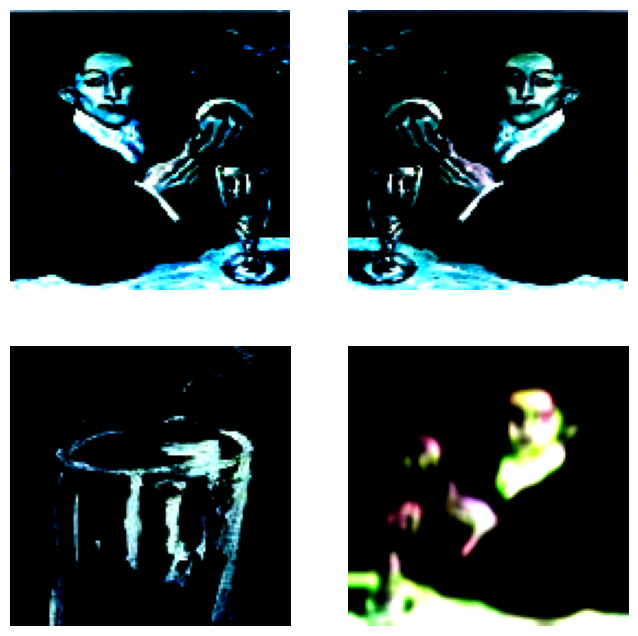

In [71]:
import random
r = random.randint(0, len(train_ul)-1)

img_ul, y = train_ul[r]
img_ur, y = train_ur[r]
img_ll, y = train_ll[r]
img_lr, y = train_lr[r]

print("Label:", y, train_df.iloc[r]["genre"])


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0,0].imshow((img_ul).permute(1,2,0).cpu().numpy())
axes[0,0].axis("off")

axes[0,1].imshow((img_ur).permute(1,2,0).cpu().numpy())
axes[0,1].axis("off")

axes[1,0].imshow((img_ll).permute(1,2,0).cpu().numpy())
axes[1,0].axis("off")

axes[1,1].imshow((img_lr).permute(1,2,0).cpu().numpy())
axes[1,1].axis("off")

plt.show()


# ReLU

In [72]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [73]:
import numpy as np
import torch

NUM_CLASSES = len(genre_to_label)

# labels must be integers 0..C-1 (you already have that)
labels_train = train_df["label"].values  # shape (N_train,)

# counts per class, ordered by label index
class_counts = np.bincount(labels_train, minlength=NUM_CLASSES).astype(float)
print("class_counts:", class_counts)

# inverse-frequency weights (rarer classes get higher weight)
class_weights = 1.0 / class_counts
# optional: normalize so average weight ~1
class_weights = class_weights * (NUM_CLASSES / class_weights.sum())
print("class_weights:", class_weights)

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)


class_counts: [48. 48. 18. 78. 44. 48. 18.  6. 16. 26. 11.]
class_weights: [0.40367836 0.40367836 1.07647562 0.24841745 0.44037639 0.40367836
 1.07647562 3.22942686 1.21103507 0.74525235 1.76150556]


In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F

NUM_CLASSES = len(genre_to_label)

class ConvFreeBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.padding = padding
        self.unfold = nn.Unfold(kernel_size=kernel_size,
                                padding=padding,
                                stride=1)
        self.fc = nn.Linear(in_channels * kernel_size * kernel_size,
                            out_channels)

    def forward(self, x):
        B, C_in, H, W = x.shape
        patches = self.unfold(x)            # (B, C_in * k * k, H * W)
        patches = patches.transpose(1, 2)   # (B, H * W, C_in * k * k)
        patches = patches.reshape(-1, patches.shape[-1])  # (B*H*W, C_in*k*k)
        out = self.fc(patches)              # (B*H*W, C_out)
        out = F.relu(out, inplace=True)
        out = out.reshape(B, H * W, -1)     # (B, H*W, C_out)
        out = out.transpose(1, 2).reshape(B, -1, H, W)  # (B, C_out, H, W)
        return out


def max_pool_2x2_with_relu(x):
    B, C, H, W = x.shape
    assert H % 2 == 0 and W % 2 == 0, "H and W must be divisible by 2."

    x = x.reshape(B, C, H // 2, 2, W // 2, 2)
    x = x.permute(0, 1, 3, 5, 2, 4)
    x = x.reshape(B, C, 4, H // 2, W // 2)

    v0 = x[:, :, 0]
    v1 = x[:, :, 1]
    v2 = x[:, :, 2]
    v3 = x[:, :, 3]

    def max2(a, b):
        diff1 = a - b
        diff2 = b - a
        abs_diff = F.relu(diff1) + F.relu(diff2)
        return 0.5 * (a + b + abs_diff)

    m01 = max2(v0, v1)
    m23 = max2(v2, v3)
    m   = max2(m01, m23)
    return m


class SmallConvFreeNetMultiDepth(nn.Module):
    """
    Same as your SmallConvFreeNet, but expecting 12 input channels
    (4 views * 3 channels each).
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Input: (B, 12, 128, 128)  <-- changed here
        self.block1 = ConvFreeBlock(12, 32, kernel_size=3, padding=1)
        self.block2 = ConvFreeBlock(32, 64, kernel_size=3, padding=1)
        self.block3 = ConvFreeBlock(64, 128, kernel_size=3, padding=1)

        self.dropout1 = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (B, 12, 128, 128)
        x = self.block1(x)              # (B, 32, 128, 128)
        x = max_pool_2x2_with_relu(x)   # (B, 32, 64, 64)

        x = self.block2(x)              # (B, 64, 64, 64)
        x = max_pool_2x2_with_relu(x)   # (B, 64, 32, 32)

        x = self.block3(x)              # (B, 128, 32, 32)
        x = max_pool_2x2_with_relu(x)   # (B, 128, 16, 16)

        x = x.mean(dim=(2, 3))          # (B, 128)

        x = self.dropout1(x)
        x = F.relu(self.fc1(x), inplace=True)
        x = self.dropout2(x)
        logits = self.fc2(x)
        return logits

    def predict_proba(self, x):
        logits = self.forward(x)
        return F.softmax(logits, dim=1)


In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F

NUM_CLASSES = len(genre_to_label)


class ConvFreeBlock(nn.Module):
    """
    Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1)
    implemented as: Unfold + Linear + ReLU.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.padding = padding
        self.unfold = nn.Unfold(kernel_size=kernel_size,
                                padding=padding,
                                stride=1)
        self.fc = nn.Linear(in_channels * kernel_size * kernel_size,
                            out_channels)

    def forward(self, x):
        # x: (B, C_in, H, W)
        B, C_in, H, W = x.shape

        # (B, C_in * k * k, H * W)
        patches = self.unfold(x)

        # (B, H * W, C_in * k * k)
        patches = patches.transpose(1, 2)

        # merge batch and spatial dims: (B * H * W, C_in * k * k)
        patches = patches.reshape(-1, patches.shape[-1])

        # apply Linear: (B * H * W, C_out)
        out = self.fc(patches)

        # ReLU activation
        out = F.relu(out, inplace=True)

        # reshape back to (B, H * W, C_out)
        out = out.reshape(B, H * W, -1)

        # (B, C_out, H, W)
        out = out.transpose(1, 2).reshape(B, -1, H, W)
        return out


def max_pool_2x2_with_relu(x):
    """
    2x2 max pooling using only linear ops + ReLU.
    x: (B, C, H, W) with H,W even.
    returns: (B, C, H/2, W/2)
    """
    B, C, H, W = x.shape
    assert H % 2 == 0 and W % 2 == 0, "H and W must be divisible by 2."

    # reshape into 2x2 patches
    # (B, C, H/2, 2, W/2, 2)
    x = x.reshape(B, C, H // 2, 2, W // 2, 2)

    # bring pooling-dim forward: (B, C, 2, 2, H/2, W/2)
    x = x.permute(0, 1, 3, 5, 2, 4)

    # flatten pooling dimension: (B, C, 4, H/2, W/2)
    x = x.reshape(B, C, 4, H // 2, W // 2)

    v0 = x[:, :, 0]  # (B, C, H/2, W/2)
    v1 = x[:, :, 1]
    v2 = x[:, :, 2]
    v3 = x[:, :, 3]

    def max2(a, b):
        # max(a,b) = 0.5 * (a + b + |a-b|)
        # |a-b| = ReLU(a-b) + ReLU(b-a)
        diff1 = a - b
        diff2 = b - a
        abs_diff = F.relu(diff1) + F.relu(diff2)
        return 0.5 * (a + b + abs_diff)

    m01 = max2(v0, v1)
    m23 = max2(v2, v3)
    m = max2(m01, m23)  # (B, C, H/2, W/2)
    return m


class SmallConvFreeNet(nn.Module):
    """
    Replica of your SmallCNN, but using only:
    - Linear layers
    - ReLU
    - Pooling expressed via Linear + ReLU
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        # Input: (B, 3, 128, 128)
        self.block1 = ConvFreeBlock(3, 32, kernel_size=3, padding=1)
        self.block2 = ConvFreeBlock(32, 64, kernel_size=3, padding=1)
        self.block3 = ConvFreeBlock(64, 128, kernel_size=3, padding=1)

        self.dropout1 = nn.Dropout(p=0.5)
        self.fc1 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        # (B, 3, 128, 128)
        x = self.block1(x)              # -> (B, 32, 128, 128)
        x = max_pool_2x2_with_relu(x)   # -> (B, 32, 64, 64)

        x = self.block2(x)              # -> (B, 64, 64, 64)
        x = max_pool_2x2_with_relu(x)   # -> (B, 64, 32, 32)

        x = self.block3(x)              # -> (B, 128, 32, 32)
        x = max_pool_2x2_with_relu(x)   # -> (B, 128, 16, 16)

        # global average pooling: (B, 128, 1, 1) -> (B, 128)
        x = x.mean(dim=(2, 3))

        x = self.dropout1(x)
        x = F.relu(self.fc1(x), inplace=True)
        x = self.dropout2(x)
        logits = self.fc2(x)
        return logits

    def predict_proba(self, x):
        """Optional: apply Softmax to get probabilities."""
        logits = self.forward(x)
        return F.softmax(logits, dim=1)


In [76]:
# Training loop for a single model
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
from torch.optim import AdamW
from tqdm import tqdm

# assumes you already defined:
# class SmallConvFreeNet(nn.Module): ...
# and a global `device` 

def train_one_model(
    train_loader,
    val_loader,
    num_epochs: int = 10,
    lr: float = 1e-3,
    class_weights: torch.Tensor | None = None,
    model_cls=SmallConvFreeNet,  # <- default to conv-free model
):
    # instantiate the chosen model (conv-free by default)
    model = model_cls().to(device)

    # handle optional class weights on the correct device
    if class_weights is not None:
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_acc = 0.0
    best_state   = None
    history = {
        "train_loss": [],
        "train_acc":  [],
        "val_loss":   [],
        "val_acc":    [],
    }

    for epoch in range(num_epochs):
        # ---------- training ----------
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0

        for imgs, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs}",
            leave=False
        ):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(imgs)

            # weighted CE if class_weights is not None
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---------- validation ----------
        model.eval()
        val_loss = 0.0
        val_total = 0
        val_correct = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(imgs)
                loss = criterion(logits, labels)  # same criterion (weighted or not)

                val_loss    += loss.item() * imgs.size(0)
                _, preds    = logits.max(1)
                val_total   += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}"
        )

        # track best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = model.state_dict()

    # restore best model (early-stopping style)
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Best val_acc ({model_cls.__name__}): {best_val_acc:.3f}")
    return model, history


In [77]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_ld_q = DataLoader(
    train_md,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
val_ld_q = DataLoader(
    val_md,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)


In [92]:
model_deep, history_deep = train_one_model(
    train_ld_q,
    val_ld_q,
    num_epochs=50,
    lr=3e-3,
    class_weights=class_weights_t,
    model_cls=SmallConvFreeNetMultiDepth,  # 12-channel version
)


Epoch 01 | train_loss=2.3955, train_acc=0.136 | val_loss=2.4105, val_acc=0.159


Epoch 02 | train_loss=2.3276, train_acc=0.172 | val_loss=2.5416, val_acc=0.182


Epoch 03 | train_loss=2.2852, train_acc=0.252 | val_loss=2.4796, val_acc=0.136


Epoch 04 | train_loss=2.2248, train_acc=0.260 | val_loss=2.4478, val_acc=0.091


Epoch 05 | train_loss=2.1777, train_acc=0.249 | val_loss=2.4130, val_acc=0.136


...

Epoch 46 | train_loss=1.5480, train_acc=0.429 | val_loss=2.3995, val_acc=0.386


Epoch 47 | train_loss=1.5217, train_acc=0.435 | val_loss=2.4793, val_acc=0.386


Epoch 48 | train_loss=1.5368, train_acc=0.427 | val_loss=2.4014, val_acc=0.341


Epoch 49 | train_loss=1.4758, train_acc=0.427 | val_loss=2.3167, val_acc=0.341


Epoch 50 | train_loss=1.4948, train_acc=0.440 | val_loss=2.3035, val_acc=0.364
Best val_acc (SmallConvFreeNetMultiDepth): 0.432


In [ ]:

# save the weights
# torch.save(model_deep.state_dict(), "model_convfree_weights_36.pth")

# to load them later:
# model_deep = SmallConvFreeNet()
# model_deep.load_state_dict(torch.load("model_convfree_weights_sad_35.pth"))

# Load the model

In [78]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) instantiate the SAME architecture
model = SmallConvFreeNetMultiDepth(num_classes=NUM_CLASSES).to(device)

# 2) load weights
state_dict = torch.load("08 Clasificacion de Movimientos Artisticos/modelos/model_convfree_weights_36.pth", map_location=device)
model.load_state_dict(state_dict)

# now `model` contains the trained weights and you can continue training

C:\Users\herie\AppData\Local\Temp\ipykernel_10344\2675708775.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("08 Clasificacion de Movimientos Art

<All keys matched successfully>

In [79]:
def train_one_model(
    train_loader,
    val_loader,
    num_epochs: int = 10,
    lr: float = 1e-3,
    class_weights: torch.Tensor | None = None,
    model_cls=SmallConvFreeNetMultiDepth,
    model: nn.Module | None = None,   # <- new optional argument
):
    # instantiate or reuse
    if model is None:
        model = model_cls().to(device)
    else:
        model = model.to(device)

    # loss function
    if class_weights is not None:
        class_weights = class_weights.to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_val_acc = 0.0
    best_state   = None
    history = {
        "train_loss": [],
        "train_acc":  [],
        "val_loss":   [],
        "val_acc":    [],
    }

    for epoch in range(num_epochs):
        # ---------- training ----------
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0

        for imgs, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{num_epochs}",
            leave=False
        ):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(imgs)

            # weighted CE if class_weights is not None
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---------- validation ----------
        model.eval()
        val_loss = 0.0
        val_total = 0
        val_correct = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(imgs)
                loss = criterion(logits, labels)  # same criterion (weighted or not)

                val_loss    += loss.item() * imgs.size(0)
                _, preds    = logits.max(1)
                val_total   += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}"
        )

        # track best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = model.state_dict()

    # restore best model (early-stopping style)
    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Best val_acc ({model_cls.__name__}): {best_val_acc:.3f}")
    return model, history



In [80]:
# 1) Create model and load weights
model_loaded = SmallConvFreeNetMultiDepth(num_classes=NUM_CLASSES)
model_loaded.load_state_dict(torch.load("08 Clasificacion de Movimientos Artisticos/modelos/model_convfree_weights_36.pth", map_location=device))

# 2) Call train_one_model, passing this model
model_resumed, history_resumed = train_one_model(
    train_ld_q,
    val_ld_q,
    num_epochs=50,                # extra epochs
    lr=3e-4,                      # maybe slightly smaller LR for fine-tuning
    class_weights=class_weights_t,
    model_cls=SmallConvFreeNetMultiDepth,
    model=model_loaded,          # <- reuse weights
)


C:\Users\herie\AppData\Local\Temp\ipykernel_10344\4107052698.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_loaded.load_state_dict(torch.load("08 Clasificacion de

Epoch 01 | train_loss=1.4567, train_acc=0.440 | val_loss=2.1956, val_acc=0.364


Epoch 02 | train_loss=1.3855, train_acc=0.452 | val_loss=2.3382, val_acc=0.386


Epoch 03 | train_loss=1.4034, train_acc=0.476 | val_loss=2.1166, val_acc=0.432


Epoch 04 | train_loss=1.3960, train_acc=0.474 | val_loss=2.3794, val_acc=0.409


...

Epoch 46 | train_loss=1.3109, train_acc=0.493 | val_loss=2.5380, val_acc=0.409


Epoch 47 | train_loss=1.2506, train_acc=0.510 | val_loss=2.4904, val_acc=0.409


Epoch 48 | train_loss=1.2571, train_acc=0.529 | val_loss=2.5509, val_acc=0.364


Epoch 49 | train_loss=1.2362, train_acc=0.501 | val_loss=2.6028, val_acc=0.386


Epoch 50 | train_loss=1.2450, train_acc=0.521 | val_loss=2.4047, val_acc=0.432
Best val_acc (SmallConvFreeNetMultiDepth): 0.477


In [84]:
model_deep = model_resumed
history_deep = history_resumed

In [ ]:
# # 2) Call train_one_model, passing this model
# model_resumed2, history_resumed = train_one_model(
#     train_ld_q,
#     val_ld_q,
#     num_epochs=50,                # extra epochs
#     lr=3e-3,                      # maybe slightly smaller LR for fine-tuning
#     class_weights=class_weights_t,
#     model_cls=SmallConvFreeNetMultiDepth,
#     model=model_resumed,          # <- reuse weights
# )


Epoch 01 | train_loss=1.5392, train_acc=0.463 | val_loss=2.5913, val_acc=0.318


Epoch 02 | train_loss=1.5231, train_acc=0.449 | val_loss=2.2101, val_acc=0.364


Epoch 03 | train_loss=1.3772, train_acc=0.468 | val_loss=2.7440, val_acc=0.386


Epoch 04 | train_loss=1.4587, train_acc=0.479 | val_loss=2.4219, val_acc=0.364


Epoch 05 | train_loss=1.4312, train_acc=0.465 | val_loss=2.4797, val_acc=0.455


...

Epoch 32 | train_loss=1.2388, train_acc=0.535 | val_loss=2.7655, val_acc=0.386


Epoch 33 | train_loss=1.3250, train_acc=0.546 | val_loss=2.5553, val_acc=0.318


Epoch 34 | train_loss=1.2111, train_acc=0.546 | val_loss=2.4563, val_acc=0.364


Epoch 35 | train_loss=1.2334, train_acc=0.546 | val_loss=2.3947, val_acc=0.432


KeyboardInterrupt: 

# Visualización del modelo

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import style
style.mpl_apply()


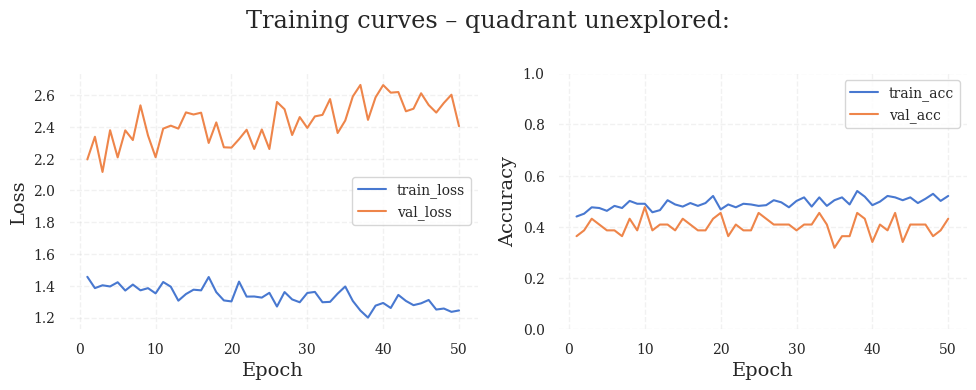

In [85]:

import matplotlib.pyplot as plt

hist_q = history_deep  # replace with hist_q from training above


epochs = range(1, len(hist_q["train_loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.suptitle(f"Training curves – quadrant unexplored:")

# --- Loss ---
plt.subplot(1, 2, 1)
plt.plot(epochs, hist_q["train_loss"], label="train_loss")
plt.plot(epochs, hist_q["val_loss"],   label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Accuracy ---
if "train_acc" in hist_q:
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_q["train_acc"], label="train_acc")
    plt.plot(epochs, hist_q["val_acc"],   label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    # fallback if you didn't re-train with train_acc stored
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist_q["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Val accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [86]:
ds = val_md  # change for each quadrant: val_ul, val_ur, val_ll, val_lr
loader = DataLoader(
    ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

all_preds = []
all_labels = []

model_deep = model
model_q = model_deep.to(device)
model_q.eval()

with torch.no_grad():
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model_q(imgs)
        _, preds = logits.max(1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)

# import confusion_matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
# TPR_c = CM[c,c] / sum_j CM[c,j]
denom = cm.sum(axis=1).clip(min=1)  # avoid division by zero
tpr = cm.diagonal() / denom

print("Confusion matrix:\n", cm)
print("TPR:", tpr)


Confusion matrix:
 [[2 1 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 1 2 0 0]
 [1 0 1 0 0 0 1 0 0 1 0]
 [0 0 1 0 0 0 2 0 0 0 1]
 [0 0 0 0 4 0 0 0 0 0 0]
 [0 0 0 0 0 1 3 0 0 0 0]
 [0 0 0 0 0 2 2 0 0 0 0]
 [1 0 0 0 0 1 0 1 1 0 0]
 [0 1 0 0 0 0 0 0 3 0 0]
 [0 0 0 0 0 0 0 0 3 0 1]
 [0 2 0 0 0 0 1 0 0 0 1]]
TPR: [0.5  0.   0.25 0.   1.   0.25 0.5  0.25 0.75 0.   0.25]


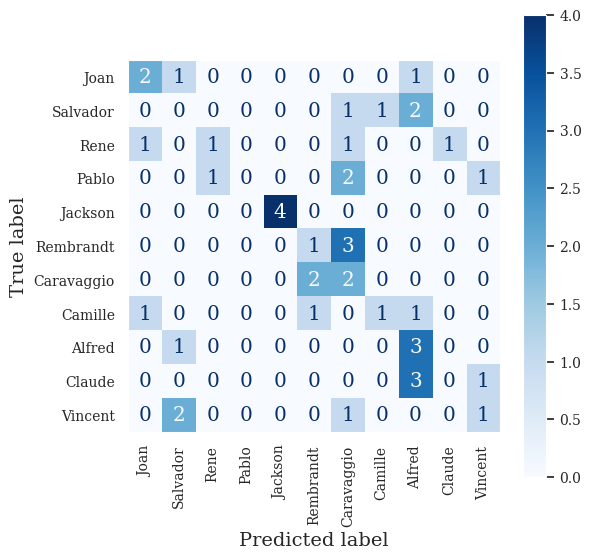

In [87]:
from sklearn.metrics import ConfusionMatrixDisplay

# plot confusion matrix as heatmap
inv_genre = {v: k for k, v in genre_to_label.items()}
class_names = [inv_genre[i] for i in range(len(genre_to_label))]
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
plt.grid(False)
# rotate x labels
plt.xticks(rotation=90)
plt.show()

In [88]:
ds = val_md  # change for each quadrant: val_ul, val_ur, val_ll, val_lr
loader = DataLoader(
    ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

all_preds = []
all_labels = []

model_q = model_deep.to(device)
model_q.eval()

with torch.no_grad():
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model_q(imgs)
        _, preds = logits.max(1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_true = np.concatenate(all_labels)
y_pred = np.concatenate(all_preds)


painter_to_genre = {
    "Joan": "Surrealismo",
    "Salvador": "Surrealismo",
    "Rene": "Surrealismo",
    "Pablo": "Cubismo",
    "Jackson": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille": "Impresionismo",
    "Alfred": "Impresionismo",
    "Claude": "Impresionismo",
    "Vincent": "Impresionismo",  
}

genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}

# Map painter labels to genre labels
painter_to_genre_label = [genre_to_label[painter_to_genre[p]] for p in painter_to_genre.keys()]
y_pred_genre = np.array([painter_to_genre_label[p] for p in y_pred])
y_true_genre = np.array([painter_to_genre_label[p] for p in y_true])

# import confusion_matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_genre, y_pred_genre, labels=np.arange(len(genre_to_label)))
# TPR_c = CM[c,c] / sum_j CM[c,j]
denom = cm.sum(axis=1).clip(min=1)  # avoid division by zero
tpr = cm.diagonal() / denom

print("Confusion matrix:\n", cm)
print("TPR (Sensitivity/Recall per class):", tpr)

# Additional metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_true_genre, y_pred_genre)
precision = precision_score(y_true_genre, y_pred_genre, average=None)
recall = recall_score(y_true_genre, y_pred_genre, average=None)  # same as tpr
f1 = f1_score(y_true_genre, y_pred_genre, average=None)
f1_macro = f1_score(y_true_genre, y_pred_genre, average='macro')

# Specificity per class
num_classes = len(genre_to_label)
specificity = []
for c in range(num_classes):
    tp = cm[c, c]
    fn = cm[c, :].sum() - tp
    fp = cm[:, c].sum() - tp
    tn = cm.sum() - (tp + fn + fp)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity.append(spec)
specificity = np.array(specificity)

print("Accuracy:", acc)
print("Precision per class:", precision)
print("Recall (Sensitivity) per class:", recall)
print("Specificity per class:", specificity)
print("F1 per class:", f1)
print("F1 Macro:", f1_macro)


Confusion matrix:
 [[4 0 0 1 7]
 [2 0 0 1 1]
 [0 0 4 0 0]
 [0 0 0 8 0]
 [4 0 0 3 9]]
TPR (Sensitivity/Recall per class): [0.33333333 0.         1.         1.         0.5625    ]
Accuracy: 0.5681818181818182
Precision per class: [0.4        0.         1.         0.61538462 0.52941176]
Recall (Sensitivity) per class: [0.33333333 0.         1.         1.         0.5625    ]
Specificity per class: [0.8125     1.         1.         0.86111111 0.71428571]
F1 per class: [0.36363636 0.         1.         0.76190476 0.54545455]
F1 Macro: 0.5341991341991342


c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


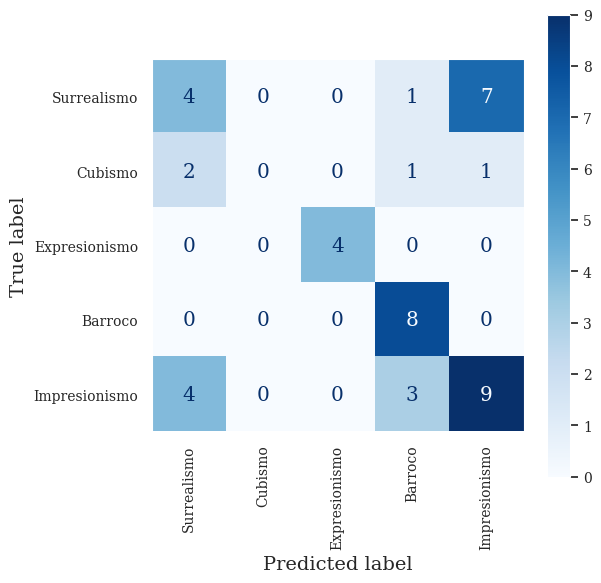

In [89]:

from sklearn.metrics import ConfusionMatrixDisplay

# plot confusion matrix as heatmap
class_names = ["Surrealismo", "Cubismo", "Expresionismo", "Barroco", "Impresionismo"]
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues')
plt.grid(False)
# rotate x labels
plt.xticks(rotation=90)
plt.show()

